# Air Canada App Review Analysis

In [29]:
!pip install wordcloud -q
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
from collections import Counter

# Download the packages
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Thoma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Thoma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Thoma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Thoma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
# Loading Dataset

df = pd.read_csv("air_canada_reviews.csv")

# Remove duplicate reviews
df = df.drop_duplicates(subset=["content", "date"])

df.head()


,date,content,score
0,2026-07-26 18:31:07,we had the oldest plane ever! YYZ to Calgary w...,3
1,2026-07-26 14:20:46,"Please, I make my flight purchase partly based...",2
2,2026-07-26 12:01:57,I have a Google Pixel 10a and a Canadian passp...,1
3,2026-07-26 07:54:34,very easy and informative app,5
4,2026-07-26 06:01:57,Why do I need to manually provide all flight d...,2


In [31]:
# Checking data

df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 6258 entries, 0 to 6257
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   date     6258 non-null   str  
 1   content  6257 non-null   str  
 2   score    6258 non-null   int64
dtypes: int64(1), str(2)
memory usage: 146.8 KB


date       0
content    1
score      0
dtype: int64

In [32]:
# Removing the short reviews and empty/missing reviews
df = df.dropna(subset = ['content']) # Removes reviews with missing content
df['review_length'] = df['content'].str.len()

df = df[df['review_length'] > 5] # Keeps reviews with more than 5 characters
df.info()

<class 'pandas.DataFrame'>
Index: 6094 entries, 0 to 6257
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   date           6094 non-null   str  
 1   content        6094 non-null   str  
 2   score          6094 non-null   int64
 3   review_length  6094 non-null   int64
dtypes: int64(2), str(2)
memory usage: 238.0 KB


***Before analysis, the raw file of 6,258 reviews was cleaned in three steps. Duplicate rows with same review and date were removed, one row with missing text was dropped, and reviews of five characters or fewer were filtered out as too short to carry meaning. This left 6094 usable reviews for the study.***

In [33]:
# Sentiment Score (positive, negative, and neutral)
def sentiment_score(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df["sentiment"] = df["score"].apply(sentiment_score)

df.head() # Confirming results



,date,content,score,review_length,sentiment
0,2026-07-26 18:31:07,we had the oldest plane ever! YYZ to Calgary w...,3,109,neutral
1,2026-07-26 14:20:46,"Please, I make my flight purchase partly based...",2,213,negative
2,2026-07-26 12:01:57,I have a Google Pixel 10a and a Canadian passp...,1,223,negative
3,2026-07-26 07:54:34,very easy and informative app,5,29,positive
4,2026-07-26 06:01:57,Why do I need to manually provide all flight d...,2,118,negative


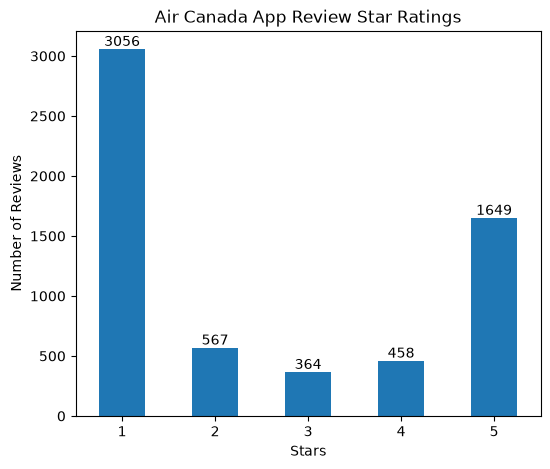

In [34]:
# Plotting Bar graph of Review
score_count = df["score"].value_counts().sort_index()

ax = score_count.plot(kind='bar', figsize =(6,5))

ax.bar_label(ax.containers[0])

plt.xticks(
    ticks = range(len(score_count)),
    labels = score_count.index,
    rotation = 0
)

plt.xlabel("Stars")
plt.ylabel("Number of Reviews")
plt.title("Air Canada App Review Star Ratings")
plt.show()

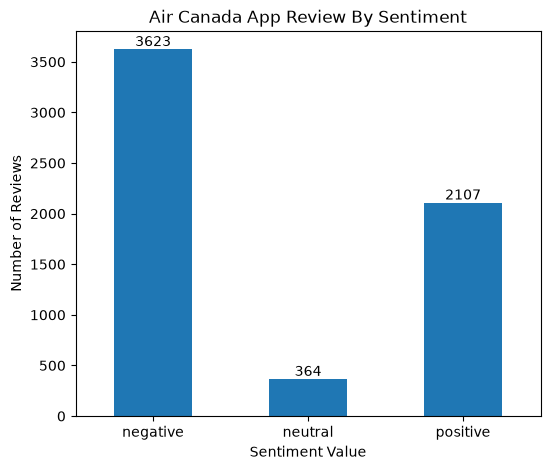

In [35]:
# Plotting Bar graph of Sentiments
sentiment_count = df["sentiment"].value_counts().sort_index()

ax = sentiment_count.plot(kind='bar', figsize =(6,5))

ax.bar_label(ax.containers[0])

plt.xticks(
    ticks = range(len(sentiment_count)),
    labels = sentiment_count.index,
    rotation = 0
)

plt.xlabel("Sentiment Value")
plt.ylabel("Number of Reviews")
plt.title("Air Canada App Review By Sentiment")
plt.show()

***The star ratings are heavily split between the extremes (negative/ positive). One-star reviews dominate at 3,056 and five-star reviews are the next largest group at 1,649, while two, three, and four-star ratings are comparatively rare. This suggests customers tend to review the app when they feel strongly, either very satisfied or very frustrated, which is common for app-store feedback and works in our favour for a positive-versus-negative classifier.***

In [36]:
# Remove neutral reviews for binary classification

df = df[df['sentiment'] != 'neutral'] # Removes neutral reviews
df['sentiment'].value_counts() # Confirming result

sentiment
negative    3623
positive    2107
Name: count, dtype: int64

***Mapping ratings to sentiment (4 to 5 stars positive, 3 neutral, 1 to 2 negative) gives 3,623 negative, 2017 positive, and 364 neutral reviews. Because the project focuses on separating clear positive from clear negative opinion, the neutral reviews were removed, leaving a binary set of 5,564. The two classes are imbalanced, roughly 64 percent negative to 36 percent positive, which we noted when reading the model results.***

In [37]:
# Preprocessing
# Lowercase, Removing Punctuation and number, Tokenize, Remove Stopwords, and Lemmatize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocessing(text):

    # lowercase
    text = text.lower()

    # remove punctuation/numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenize
    words = word_tokenize(text)

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [38]:
df['cleaned'] = df['content'].apply(preprocessing)

df = df[df['cleaned'].str.len() > 0] # remove all empty reviews after pre-processing.

df[['content','cleaned']].head() # Preview review vs cleaned review

,content,cleaned
1,"Please, I make my flight purchase partly based...",please make flight purchase partly based seat ...
2,I have a Google Pixel 10a and a Canadian passp...,google pixel canadian passport still never sca...
3,very easy and informative app,easy informative app
4,Why do I need to manually provide all flight d...,need manually provide flight detail check bagg...
5,Perfect app. Very helpful.,perfect app helpful


In [39]:
df.info() # 5730 reviews remain

<class 'pandas.DataFrame'>
Index: 5727 entries, 1 to 6257
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   date           5727 non-null   str  
 1   content        5727 non-null   str  
 2   score          5727 non-null   int64
 3   review_length  5727 non-null   int64
 4   sentiment      5727 non-null   str  
 5   cleaned        5727 non-null   str  
dtypes: int64(2), str(4)
memory usage: 313.2 KB


***Mapping ratings to sentiment (4 to 5 stars positive, 3 neutral, 1 to 2 negative) gives 3,623 negative, 2,107 positive, and 364 neutral reviews. Because the project focuses on separating clear positive from clear negative opinion, the neutral reviews were removed, leaving a binary set of 5,727 (after preprocessing). The two classes are not balanced, roughly 64 percent negative to 36 percent positive, which we keep in mind when reading the model results.***

In [40]:
# Using TFIDF to convert into numerical features
tfidf = TfidfVectorizer(
    max_features = 2000,
    ngram_range = (1,2)
)



In [41]:
# Train Test Split 80 / 20

X = tfidf.fit_transform(df['cleaned'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1234, stratify= y)


In [42]:
# Training Logistic Regression and Multinomial Naive Bayes Models

model_lr = LogisticRegression(max_iter=1000)
model_nb = MultinomialNB()

# Fitting models
model_lr.fit(X_train,y_train)
model_nb.fit(X_train,y_train)

# Prediction Using test data
predict_lr = model_lr.predict(X_test)
predict_nb = model_nb.predict(X_test)



In [43]:
# Logistic Regression Model Results
print('Logistic Regression Model')
print(classification_report(y_test, predict_lr))

print('Confusion Matrix')
confusion_lr = confusion_matrix(y_test, predict_lr)

confusion_df = pd.DataFrame(
confusion_lr,
index = ['Actual Negative', 'Actual Positive'],
columns = ['Predicted Negative', 'Predicted Positive']
)

print(confusion_df, '\n')

print('The accuracy score is: ', round(accuracy_score(y_test, predict_lr),4))

Logistic Regression Model
              precision    recall  f1-score   support

    negative       0.89      0.97      0.93       725
    positive       0.93      0.80      0.86       421

    accuracy                           0.90      1146
   macro avg       0.91      0.88      0.89      1146
weighted avg       0.91      0.90      0.90      1146

Confusion Matrix
                 Predicted Negative  Predicted Positive
Actual Negative                 700                  25
Actual Positive                  85                 336 

The accuracy score is:  0.904


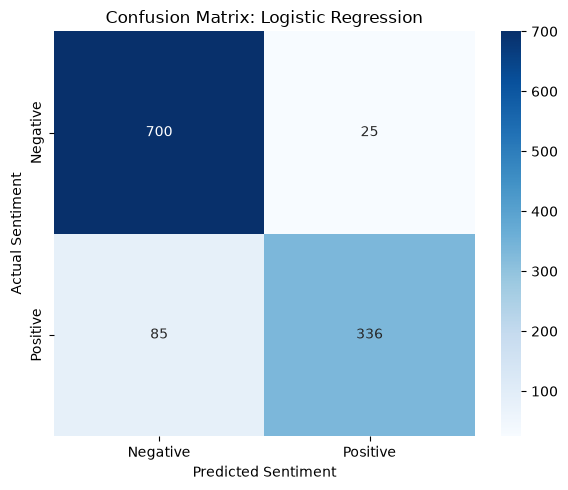

In [44]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix: Logistic Regression')
plt.tight_layout()
plt.show()

In [45]:
# Multinomial Model Results

print('Multinomial Naive Bayes Model')
print(classification_report(y_test, predict_nb))

print('Confusion Matrix')
confusion_nb = confusion_matrix(y_test, predict_nb)

confusion_df2 = pd.DataFrame(
confusion_nb,
index = ['Actual Negative', 'Actual Positive'],
columns = ['Predicted Negative', 'Predicted Positive']
)

print(confusion_df2, '\n')

print('The accuracy score is: ', round(accuracy_score(y_test, predict_nb),4))



Multinomial Naive Bayes Model
              precision    recall  f1-score   support

    negative       0.89      0.96      0.93       725
    positive       0.92      0.81      0.86       421

    accuracy                           0.90      1146
   macro avg       0.91      0.88      0.89      1146
weighted avg       0.91      0.90      0.90      1146

Confusion Matrix
                 Predicted Negative  Predicted Positive
Actual Negative                 697                  28
Actual Positive                  82                 339 

The accuracy score is:  0.904


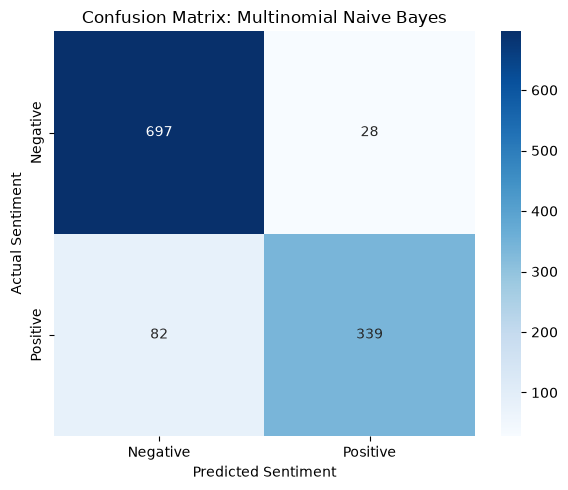

In [46]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix: Multinomial Naive Bayes')
plt.tight_layout()
plt.show()

***Both models perform almost identically, with Logistic Regression and Naive Bayes each at approximately 90.4 percent accuracy. However, accuracy alone is a little misleading here because the data is imbalanced: a model that guessed negative every time would already score about 64 percent, so the meaningful question is how well each model handles both classes. Looking at precision and recall, both models catch negative reviews very well at 96 and 97 percent recall respectively, but miss more of the positives at 80 to 81 percent recall. Precision results show positive precision is high at 93 and 92 respectively, so when the model does label a review positive it is almost always correct, even though it misses some genuine positives. The F1-score, which balances precision and recall, is about 0.93 for the negative class and 0.86 for the positive class. This also confirms that the models are strong overall while weaker at detecting positive reviews. The confusion matrix confirms this, with 71 of 395 actual positive reviews misclassified as negative by Logistic Regression.***

In [47]:
# Combine cleaned negative reviews into one text string
negative_text = ' '.join(
    df.loc[df['sentiment'] == 'negative', 'cleaned']
)

# Combine cleaned positive reviews into one text string
positive_text = ' '.join(
    df.loc[df['sentiment'] == 'positive', 'cleaned']
)

print("Negative text length:", len(negative_text))
print("Positive text length:", len(positive_text))

Negative text length: 382405
Positive text length: 114801


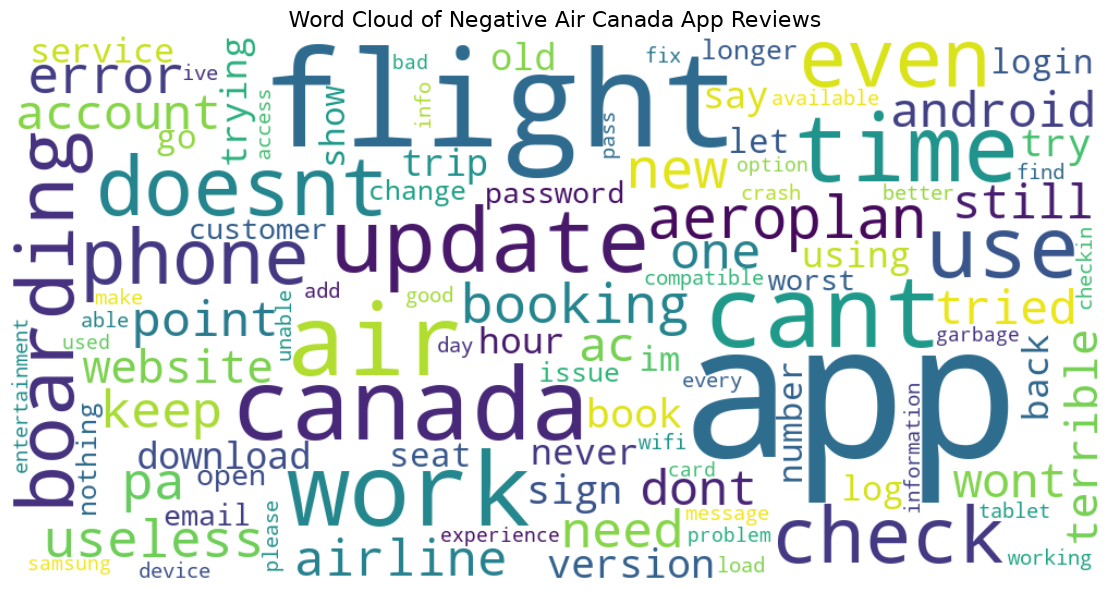

In [48]:
# Generate a word cloud (draft) for negative reviews
negative_wordcloud = WordCloud(
                                width=1000,
                                height=500,
                                background_color='white',
                                max_words=100,
                                collocations=False,
                                random_state=1234
                              ).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(
    'Word Cloud of Negative Air Canada App Reviews',
    fontsize=16
)
plt.tight_layout()
plt.show()

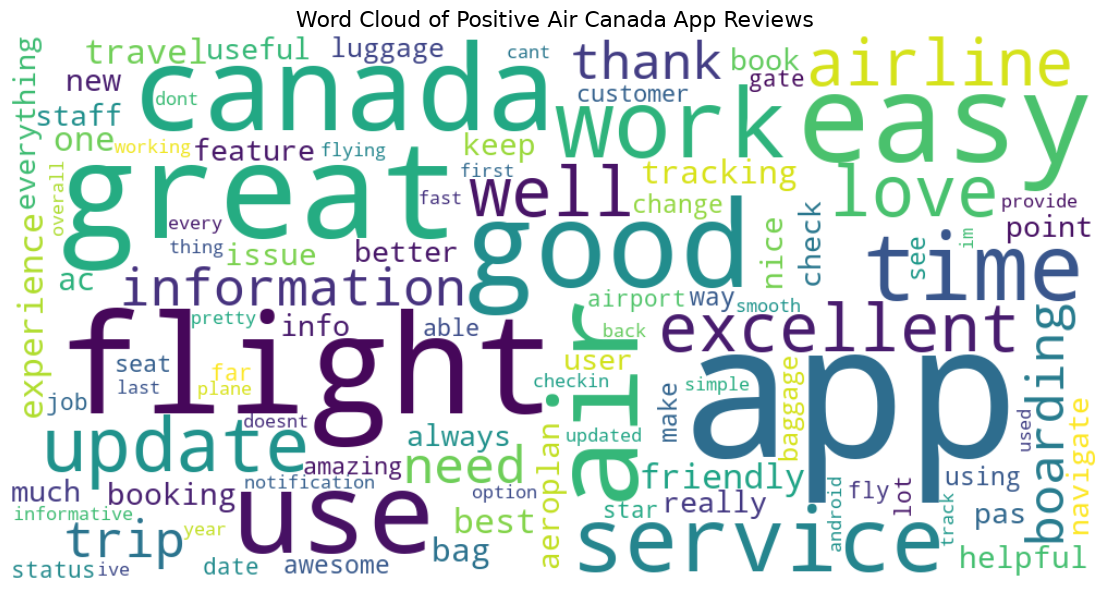

In [49]:
# Generate a word cloud for positive reviews
positive_wordcloud = WordCloud(
                                  width=1000,
                                  height=500,
                                  background_color='white',
                                  max_words=100,
                                  collocations=False,
                                  random_state=1234
                              ).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(
    'Word Cloud of Positive Air Canada App Reviews',
    fontsize=16
)
plt.tight_layout()
plt.show()

***The word clouds give a quick visual contrast between the groups. Negative reviews are dominated by words like work, cant, doesnt, update, error, and useless, pointing to app reliability and update problems. Positive reviews center on easy, great, good, service, and helpful, describing a smooth experience. The clouds are a useful overview but include generic terms such as app and flight, so the next step quantifies the complaint words more precisely.***

In [50]:
# Split all cleaned negative reviews into individual words
negative_words = negative_text.split()

# Count word frequencies
negative_word_counts = Counter(negative_words)

# Get the 20 most common words
top_20_negative_words = negative_word_counts.most_common(20)

# Convert results into a DataFrame
top_20_negative_df = pd.DataFrame(
    top_20_negative_words,
    columns=['Word', 'Frequency']
)

top_20_negative_df

,Word,Frequency
0,app,2928
1,flight,1224
2,work,669
3,canada,634
4,air,625
5,cant,623
6,time,558
7,update,494
8,use,458
9,doesnt,423


In [51]:
# Remove common words that do not represent specific complaint themes
custom_exclude_words = {
    'app', 'air', 'canada', 'aircanada', 'airline',
    'flight', 'use', 'used', 'using', 'get',
    'one', 'would', 'even', 'still', 'new',
    'time', 'phone', 'need', 'keep', 'say',
    'make', 'let', 'go', 'point', 'please'
}

filtered_negative_words = [
    word
    for word in negative_words
    if word not in custom_exclude_words
]

filtered_negative_counts = Counter(filtered_negative_words)

top_20_filtered_negative = filtered_negative_counts.most_common(20)

top_20_filtered_df = pd.DataFrame(
    top_20_filtered_negative,
    columns=['Word', 'Frequency']
)

top_20_filtered_df

,Word,Frequency
0,work,669
1,cant,623
2,update,494
3,doesnt,423
4,boarding,392
5,check,369
6,aeroplan,356
7,booking,300
8,error,289
9,useless,274


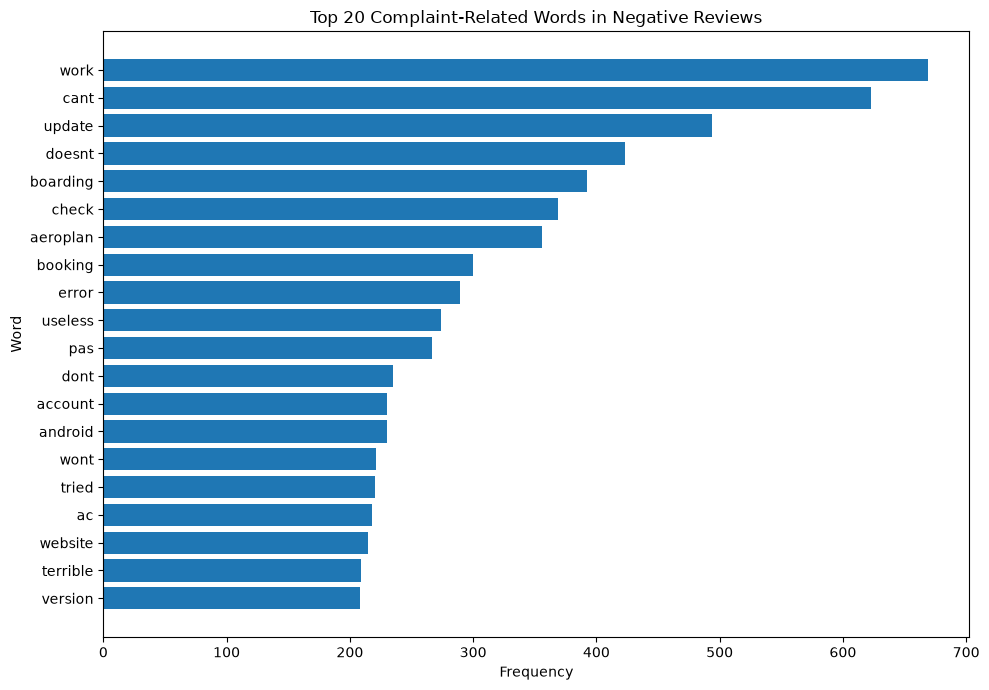

In [52]:
#Sort the data so the largest bar appears at the top
top_20_filtered_plot = top_20_filtered_df.sort_values(
    by='Frequency',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_filtered_plot['Word'],
    top_20_filtered_plot['Frequency']
)

plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title(
    'Top 20 Complaint-Related Words in Negative Reviews'
)

plt.tight_layout()
plt.show()

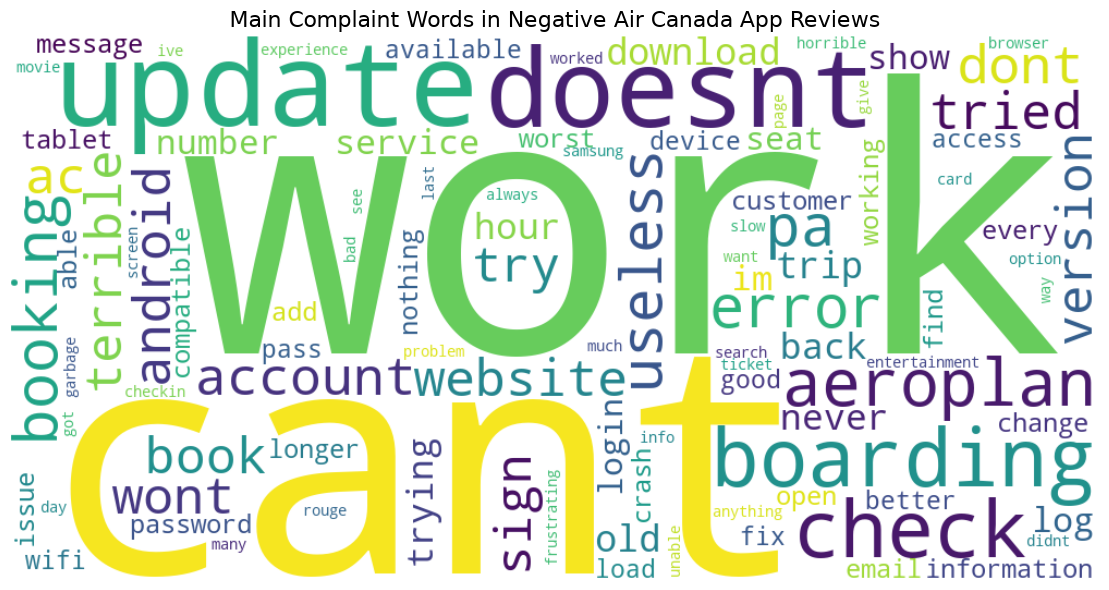

In [53]:
# Generate a word cloud (final) for negative reviews after filter useless words
filtered_negative_text = ' '.join(filtered_negative_words)

filtered_negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100,
    collocations=False,
    random_state=1234
).generate(filtered_negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(
    filtered_negative_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title(
    'Main Complaint Words in Negative Air Canada App Reviews',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [54]:
#Turn words into clear categories of what customers are actually complaining about
complaint_themes = {
    'Technical Issues': [
        'crash', 'error', 'loading', 'slow',
        'update', 'working', 'freeze', 'bug'
    ],
    'Login and Account': [
        'login', 'password', 'account',
        'signin', 'sign'
    ],
    'Booking and Check-in': [
        'booking', 'book', 'checkin',
        'boarding', 'seat'
    ],
    'Refund and Payment': [
        'refund', 'payment', 'charge',
        'credit', 'money', 'pay'
    ],
    'Delay and Cancellation': [
        'delay', 'delayed', 'cancel',
        'cancelled', 'cancellation'
    ],
    'Baggage': [
        'bag', 'baggage', 'luggage'
    ],
    'Customer Service': [
        'service', 'support', 'agent',
        'representative', 'call'
    ]
}

***Moving from impression to evidence, we counted the most frequent words in negative reviews and removed generic terms such as app, flight, and canada that appear everywhere and describe no specific problem. The filtered ranking is led by work, cant, update, doesnt, boarding, check, aeroplan, booking, error, and useless. Together these point at technical failures and trouble completing bookings and check-in rather than at the flight experience itself, which fits the fact that these are app-store reviews.***

In [55]:
#Count how many negative reviews mention each complaint theme
negative_reviews = df[
    df['sentiment'] == 'negative'
].copy()

theme_results = {}

for theme, keywords in complaint_themes.items():
    pattern = r'\b(?:' + '|'.join(keywords) + r')\b'

    theme_results[theme] = (
        negative_reviews['cleaned']
        .str.contains(pattern, regex=True)
        .sum()
    )

theme_counts_df = pd.DataFrame({
    'Complaint Theme': theme_results.keys(),
    'Number of Reviews': theme_results.values()
})

theme_counts_df = theme_counts_df.sort_values(
    by='Number of Reviews',
    ascending=False
)

theme_counts_df

,Complaint Theme,Number of Reviews
0,Technical Issues,1004
2,Booking and Check-in,781
1,Login and Account,465
6,Customer Service,285
3,Refund and Payment,162
4,Delay and Cancellation,109
5,Baggage,68


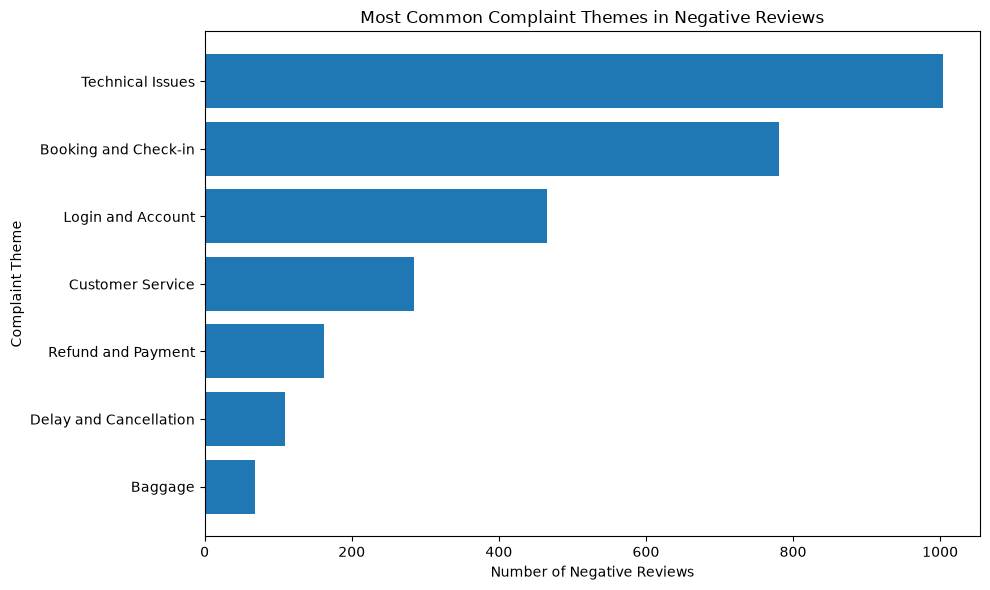

In [56]:
#Visualize the previously calculated complaint theme results in a horizontal bar chart
theme_plot = theme_counts_df.sort_values(
    by='Number of Reviews',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    theme_plot['Complaint Theme'],
    theme_plot['Number of Reviews']
)

plt.xlabel('Number of Negative Reviews')
plt.ylabel('Complaint Theme')
plt.title('Most Common Complaint Themes in Negative Reviews')

plt.tight_layout()
plt.show()

***Grouping the complaint words into themes turns the counts into a clear priority list. Technical Issues are by far the largest category, appearing in 999 negative reviews, followed by Booking and Check-in at 781 and Login and Account at 464. Other airline concerns like delays, baggage, and refunds appear far less often, confirming that customers use these reviews to complain mostly about the app itself, not the airline service. For Air Canada this points to app stability, the update process, and the booking and login flow as the highest-value areas to fix.***

***Conclusion, Recommendations and Limitations:***

This project aimed to classify Air Canada app reviews as positive or negative and to identify the issues customers raise most. After cleaning the data to 5,927 reviews and dropping neutral cases, both Logistic Regression and Naive Bayes classified sentiment with about 92 percent accuracy, performing equally well and catching negative reviews slightly better than positive ones. Further analysis on the complaints shows the negative feedback is driven mainly by technical problems, failed updates, and difficulty with booking, check-in, and login, rather than by the flight experience. 

The analysis gives Air Canada a clear set of priorities. The most pressing issue is app reliability: technical problems such as crashes and failed updates appear in 999 negative reviews, making it the largest source of frustration, so improving stability and testing updates before release should be the first priority. The booking and check-in flow (781 reviews) and account login (464 reviews) follow closely. It is also worth noting that app users complain far more about these technical issues than about delays, baggage, or refunds, so development effort is better directed toward the digital experience rather than general airline concerns. Finally, because most reviews are one-star and tend to flag problems early, Air Canada could run this sentiment pipeline on a recurring basis, such as after each app release, to track emerging issues rather than reviewing feedback manually.

Limitations of this project: the reviews are from those individuals who chose to do so on their own rather than randomly sampled and the reviews skew toward strong opinions, the neutral group was excluded so the model does not handle mixed reviews, and the themes rely on a fixed keyword list that may miss some phrasings.